## # Boston Real Estate Sale Probability - Exploratory Data Analysis

This notebook explores the Boston real estate dataset to understand the distributions of features and their relationships with sale probability.

In [12]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

## Load the Dataset

In [14]:
# Load the dataset
boston_real_estate = pd.read_csv('../data/boston_real_estate_sale_probability.csv')

# Check data dimensions
print(f"Dataset dimensions: {boston_real_estate.shape}")
print(f"Number of properties: {boston_real_estate.shape[0]}")
print(f"Number of features: {boston_real_estate.shape[1]}")

# Display first few rows
boston_real_estate.head()

Dataset dimensions: (1000, 18)
Number of properties: 1000
Number of features: 18


,years_owned,property_value,square_feet,bedrooms,bathrooms,property_age,neighborhood,distance_to_t,school_rating,property_tax,has_liens,lien_amount,mortgage_rate,income_to_mortgage_ratio,market_inventory_months,avg_days_on_market,last_transaction_date,sale_probability
0,4,803310,815,2,1.5,42,Roslindale,0.77,8.3,5273,0,0,4.41,2.91,3.4,15,2021-04-12,0.29
1,22,349396,1741,4,1.5,91,Beacon Hill,1.58,6.5,4281,0,0,2.79,3.53,4.5,42,2003-04-17,0.08
2,10,864059,746,2,1.5,15,Brighton,0.04,7.0,1000,1,959,3.42,3.16,3.7,18,2015-04-14,0.18
3,7,933175,2332,2,1.5,232,Brighton,0.11,7.2,7283,0,0,4.79,4.48,3.5,74,2018-04-13,0.44
4,2,917937,1857,2,2.0,92,Dorchester,0.88,4.4,2884,1,15952,2.57,3.67,3.3,42,2023-04-12,0.01


## Basic Data Information

Let's examine the dataset structure, data types, and check for missing values.

In [15]:
# Dataset info
print("\nDataset Information:")
boston_real_estate.info()

# Check for missing values
print("\nMissing values per column:")
boston_real_estate.isnull().sum()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   years_owned               1000 non-null   int64  
 1   property_value            1000 non-null   int64  
 2   square_feet               1000 non-null   int64  
 3   bedrooms                  1000 non-null   int64  
 4   bathrooms                 1000 non-null   float64
 5   property_age              1000 non-null   int64  
 6   neighborhood              1000 non-null   object 
 7   distance_to_t             1000 non-null   float64
 8   school_rating             1000 non-null   float64
 9   property_tax              1000 non-null   int64  
 10  has_liens                 1000 non-null   int64  
 11  lien_amount               1000 non-null   int64  
 12  mortgage_rate             1000 non-null   float64
 13  income_to_mortgage_ratio  1000 non-null   

years_owned                 0
property_value              0
square_feet                 0
bedrooms                    0
bathrooms                   0
property_age                0
neighborhood                0
distance_to_t               0
school_rating               0
property_tax                0
has_liens                   0
lien_amount                 0
mortgage_rate               0
income_to_mortgage_ratio    0
market_inventory_months     0
avg_days_on_market          0
last_transaction_date       0
sale_probability            0
dtype: int64

## Statistical Summary

Examine the distribution of numerical features.

In [16]:
# Summary statistics
print("\nSummary Statistics:")
boston_real_estate.describe().round(2)


Summary Statistics:


,years_owned,property_value,square_feet,bedrooms,bathrooms,property_age,distance_to_t,school_rating,property_tax,has_liens,lien_amount,mortgage_rate,income_to_mortgage_ratio,market_inventory_months,avg_days_on_market,sale_probability
count,1000.00,1000.00,1000.00,1000.0,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,7.33,783107.61,1814.06,2.8,2.10,93.69,0.67,7.02,4990.59,0.15,1506.25,4.52,3.46,3.62,39.91,0.26
std,6.80,288550.95,667.52,1.0,0.81,51.80,0.64,1.52,1930.30,0.36,4438.43,1.40,1.22,1.47,21.07,0.15
min,1.00,200000.00,400.00,1.0,1.00,14.00,0.00,2.30,1000.00,0.00,0.00,2.00,0.50,0.50,10.00,0.01
25%,2.00,580763.25,1349.25,2.0,1.50,56.00,0.22,6.00,3628.75,0.00,0.00,3.54,2.66,2.60,24.00,0.14
50%,5.00,775264.00,1806.50,3.0,2.00,84.00,0.48,7.10,4930.50,0.00,0.00,4.47,3.46,3.60,35.00,0.27
75%,10.00,971889.25,2266.00,3.0,2.50,121.00,0.92,8.10,6280.75,0.00,0.00,5.46,4.32,4.60,51.00,0.36
max,58.00,1707932.00,3996.00,5.0,4.00,354.00,4.61,10.00,12088.00,1.00,37602.00,8.00,7.20,7.90,139.00,0.81


## Sale Probability Distribution

Let's examine the distribution of our target variable - sale probability.


Sale probability statistics:


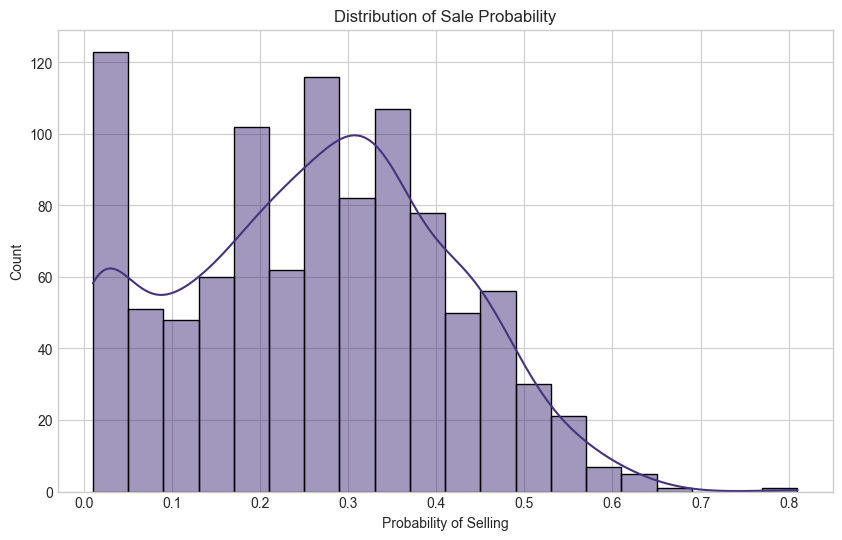

In [17]:
# Sale probability statistics
print("\nSale probability statistics:")
boston_real_estate['sale_probability'].describe()

# Plot distribution of sale probability
plt.figure(figsize=(10, 6))
sns.histplot(boston_real_estate['sale_probability'], bins=20, kde=True)
plt.title('Distribution of Sale Probability')
plt.xlabel('Probability of Selling')
plt.ylabel('Count')
plt.show()


## Save visualization of sale probability distribution

In [18]:
plt.savefig('../visualizations/sale_probability_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

## Key Feature Relationships

Visualize how key features relate to sale probability.

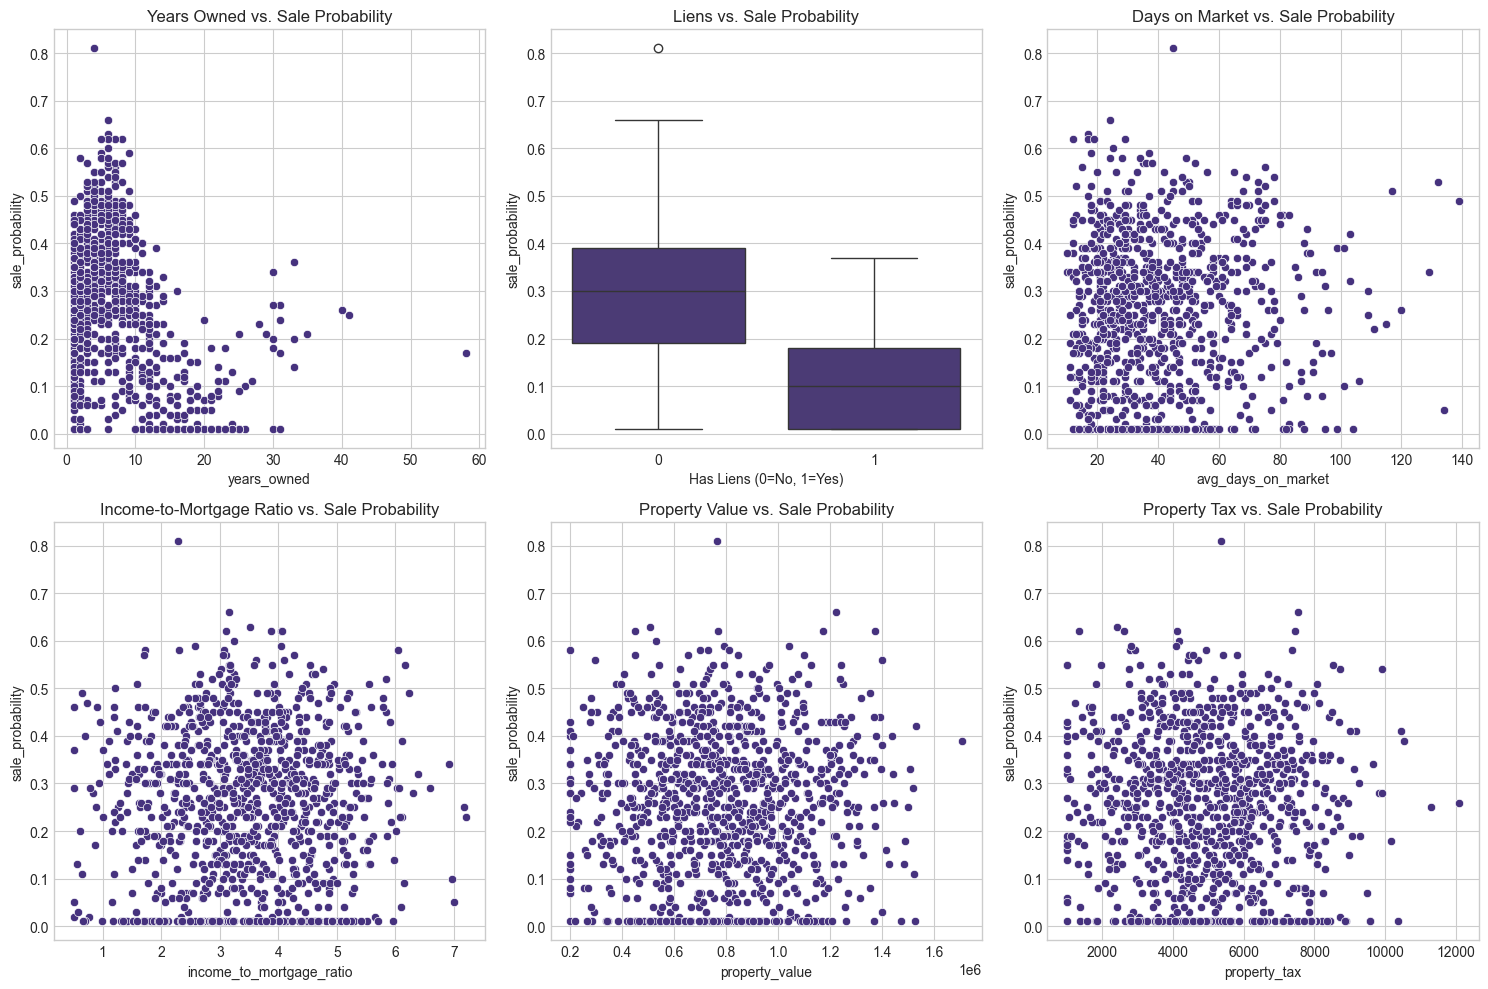

<Figure size 640x480 with 0 Axes>

In [19]:
# Visualize relationship between key features and sale probability
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
sns.scatterplot(x='years_owned', y='sale_probability', data=boston_real_estate)
plt.title('Years Owned vs. Sale Probability')

plt.subplot(2, 3, 2)
sns.boxplot(x='has_liens', y='sale_probability', data=boston_real_estate)
plt.title('Liens vs. Sale Probability')
plt.xlabel('Has Liens (0=No, 1=Yes)')

plt.subplot(2, 3, 3)
sns.scatterplot(x='avg_days_on_market', y='sale_probability', data=boston_real_estate)
plt.title('Days on Market vs. Sale Probability')

plt.subplot(2, 3, 4)
sns.scatterplot(x='income_to_mortgage_ratio', y='sale_probability', data=boston_real_estate)
plt.title('Income-to-Mortgage Ratio vs. Sale Probability')

plt.subplot(2, 3, 5)
sns.scatterplot(x='property_value', y='sale_probability', data=boston_real_estate)
plt.title('Property Value vs. Sale Probability')

plt.subplot(2, 3, 6)
sns.scatterplot(x='property_tax', y='sale_probability', data=boston_real_estate)
plt.title('Property Tax vs. Sale Probability')

plt.tight_layout()
plt.show()
plt.savefig('../visualizations/key_feature_relationships.png', dpi=300, bbox_inches='tight')

## Correlation Analysis

Examine correlations between features and sale probability.


Correlation with sale_probability:
sale_probability            1.000000
bathrooms                   0.051579
school_rating               0.041009
avg_days_on_market          0.030048
income_to_mortgage_ratio    0.013004
property_value              0.002738
bedrooms                   -0.009343
distance_to_t              -0.011297
property_age               -0.013155
square_feet                -0.014619
mortgage_rate              -0.025083
property_tax               -0.033212
market_inventory_months    -0.055566
lien_amount                -0.324261
years_owned                -0.390467
has_liens                  -0.391580
Name: sale_probability, dtype: float64


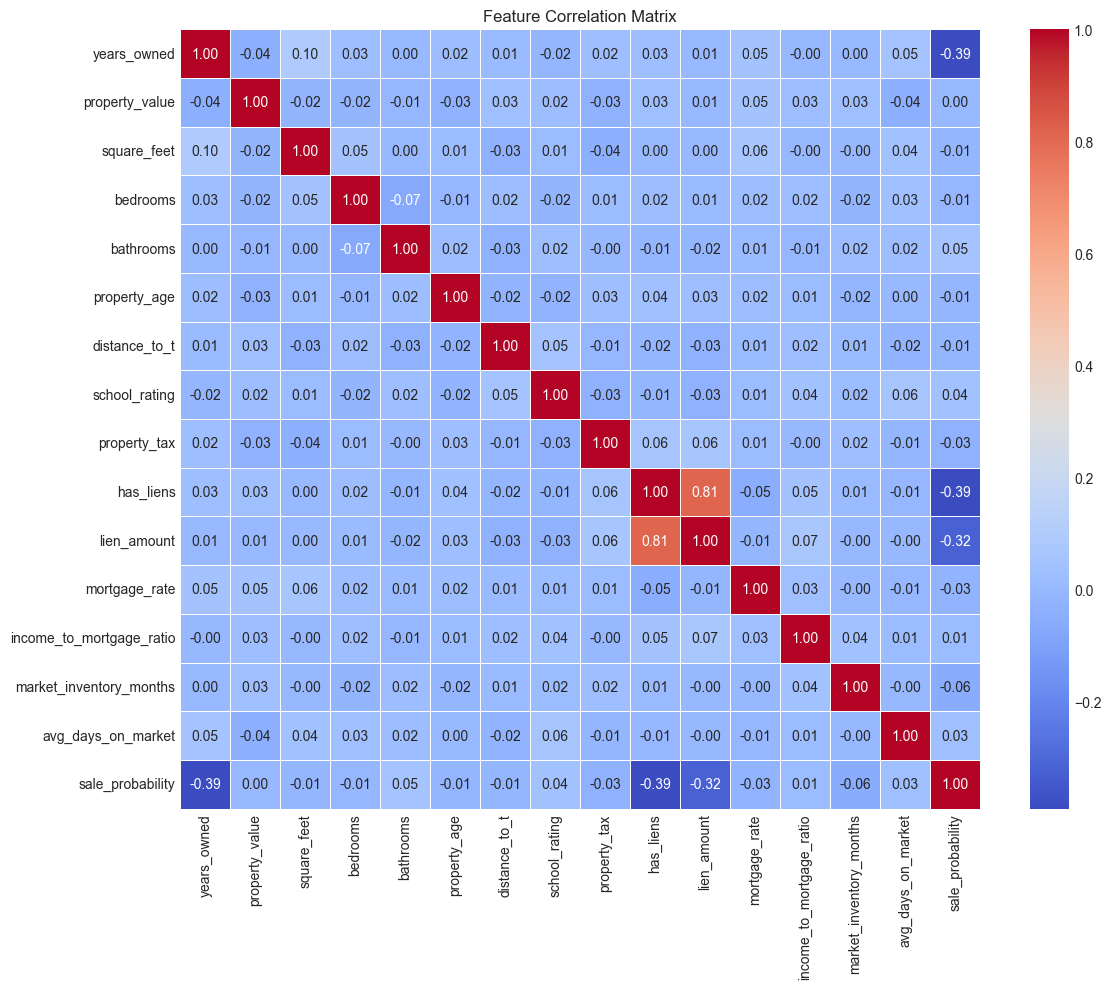

In [20]:
# Calculate correlations (exclude non-numeric columns)
correlation_matrix = boston_real_estate.select_dtypes(include=['number']).corr()
print("\nCorrelation with sale_probability:")
print(correlation_matrix['sale_probability'].sort_values(ascending=False))

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## Years Owned Analysis

The relationship between years owned and sale probability appears non-linear. Let's explore this further.

/var/folders/v3/xbsx2q495mg5szqs0rdy2kq40000gn/T/ipykernel_90308/2243817599.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  years_grouped = boston_real_estate.groupby('years_owned_bin')['sale_probability'].mean().reset_index()


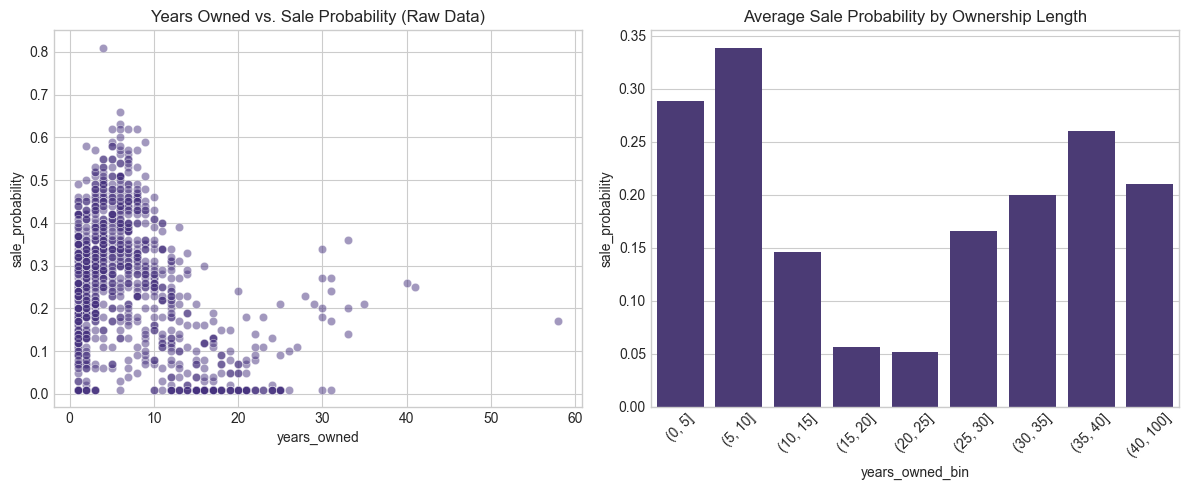

We can see the U-shaped relationship where both new purchases (5-10 years) and long-term ownership (25+ years) have higher probabilities of sale.


In [21]:
# Create a detailed analysis of years_owned
plt.figure(figsize=(12, 5))

# Bin the years owned to see average sale probability by ownership length
years_bins = [0, 5, 10, 15, 20, 25, 30, 35, 40, 100]  # Bins for years owned
boston_real_estate['years_owned_bin'] = pd.cut(boston_real_estate['years_owned'], years_bins)

# Grouped averages
years_grouped = boston_real_estate.groupby('years_owned_bin')['sale_probability'].mean().reset_index()

# Plot both scatter and grouped average
plt.subplot(1, 2, 1)
sns.scatterplot(x='years_owned', y='sale_probability', data=boston_real_estate, alpha=0.5)
plt.title('Years Owned vs. Sale Probability (Raw Data)')

plt.subplot(1, 2, 2)
sns.barplot(x='years_owned_bin', y='sale_probability', data=years_grouped)
plt.xticks(rotation=45)
plt.title('Average Sale Probability by Ownership Length')

plt.tight_layout()
plt.show()

print("We can see the U-shaped relationship where both new purchases (5-10 years) and long-term ownership (25+ years) have higher probabilities of sale.")

## Neighborhood Analysis

Let's see if certain neighborhoods have higher sale probabilities.

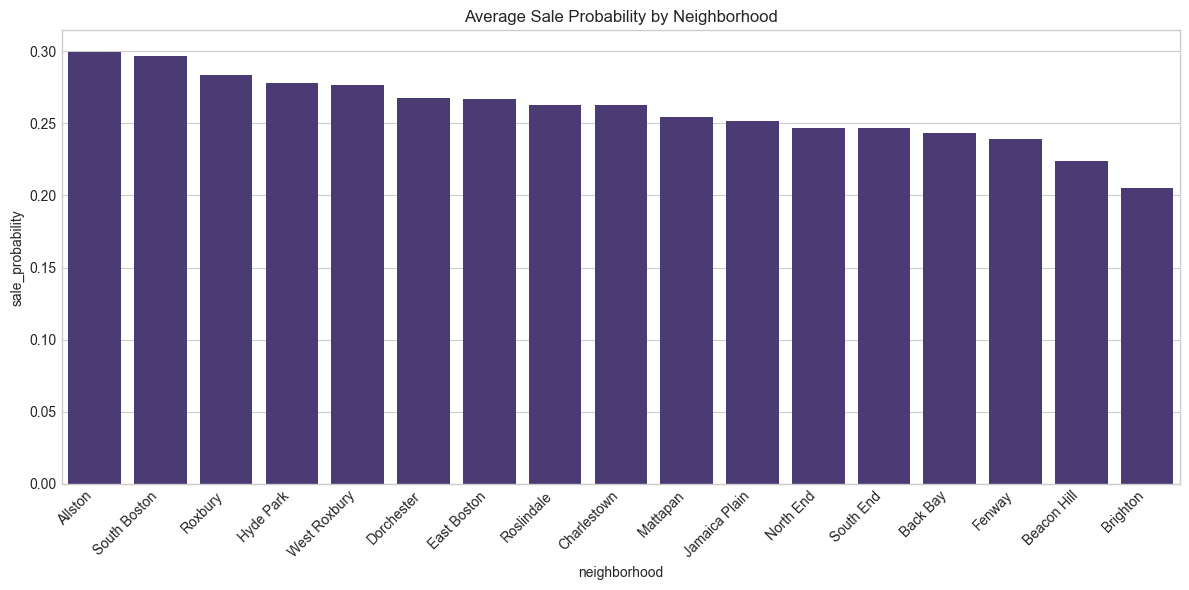

In [22]:
# Average sale probability by neighborhood
neighborhood_avg = boston_real_estate.groupby('neighborhood')['sale_probability'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='neighborhood', y='sale_probability', data=neighborhood_avg)
plt.title('Average Sale Probability by Neighborhood')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Key Insights from EDA

Based on our exploratory data analysis, we've discovered several patterns:

1. **Years Owned**: Shows a non-linear, U-shaped relationship where both newer purchases (5-10 years) and long-term ownership (25+ years) have higher probabilities of selling.

2. **Property Liens**: Properties with liens have significantly lower sale probabilities, as expected.

3. **Market Conditions**: Longer average days on market correlates with lower sale probabilities.

4. **Financial Factors**: Higher income-to-mortgage ratios tend to increase sale probability, while higher property taxes decrease it.

5. **Property Characteristics**: There are some relationships between property size/value and sale probability, but they're not as strong as other factors.

These insights will guide our feature selection and modeling approach in the next notebook.